C:\Users\Kushal Pedaprolu\AppData\Local\Temp\ipykernel_22380\1079099778.py:50: RuntimeWarning: overflow encountered in square
  val_mse.append(np.mean((y_val - val_pred)**2))
C:\Users\Kushal Pedaprolu\AppData\Local\Temp\ipykernel_22380\1079099778.py:47: RuntimeWarning: overflow encountered in square
  train_mse.append(np.mean(error**2))
C:\Users\Kushal Pedaprolu\AppData\Local\Temp\ipykernel_22380\1079099778.py:41: RuntimeWarning: overflow encountered in dot
  dw = (-2/n_samples) * np.dot(X_train.T, error)
C:\Users\Kushal Pedaprolu\AppData\Local\Temp\ipykernel_22380\1079099778.py:41: RuntimeWarning: invalid value encountered in dot
  dw = (-2/n_samples) * np.dot(X_train.T, error)
C:\Users\Kushal Pedaprolu\AppData\Local\Temp\ipykernel_22380\1079099778.py:44: RuntimeWarning: invalid value encountered in subtract
  model.w -= model.learning_rate * dw


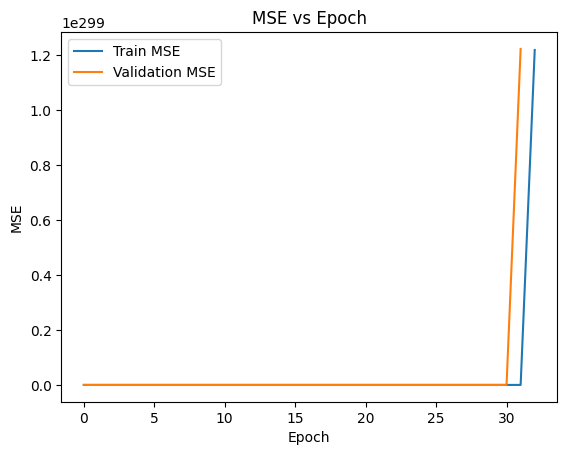

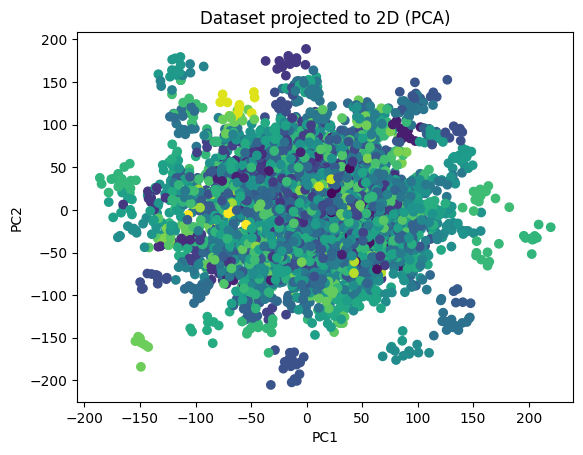

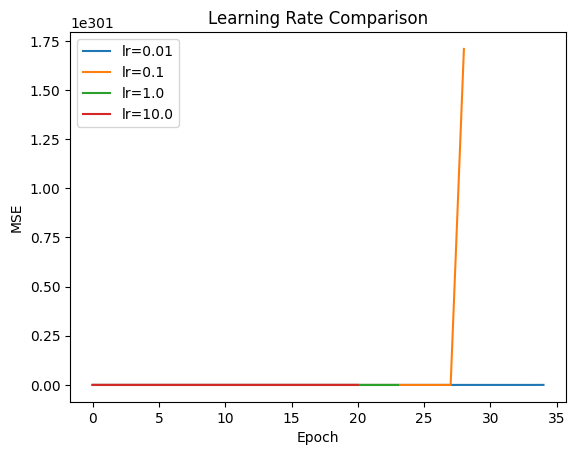

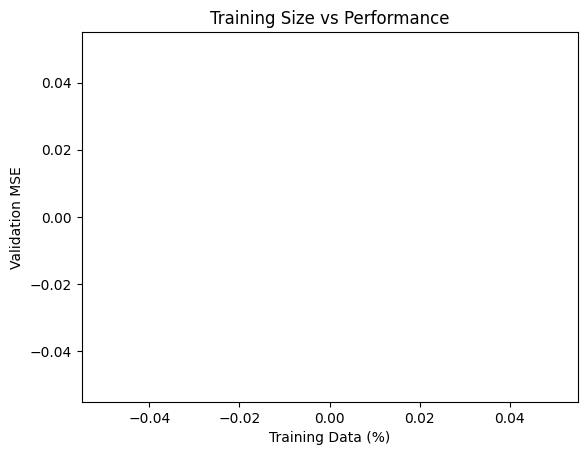

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from adaline import Adaline

# ---------------- LOAD DATASET ---------------- #

data = np.loadtxt("../IIT_H_Campus_Life_Prediction_Dataset/iit_h_mess_dataset.csv", delimiter=",", skiprows=1)

X = data[:, :-1]
y = data[:, -1]

# Standardize features (crucial for ADALINE convergence)
X_mean = np.mean(X, axis=0)
X_std = np.std(X, axis=0)
X_std[X_std == 0] = 1.0
X = (X - X_mean) / X_std

# Standardize target
y_mean = np.mean(y)
y_std = np.std(y)
y = (y - y_mean) / y_std






# ---------------- TRAIN / VALIDATION SPLIT ---------------- #

n_samples = X.shape[0]
split = int(0.8 * n_samples)

X_train = X[:split]
y_train = y[:split]

X_val = X[split:]
y_val = y[split:]


# ---------------- TRAINING LOOP (WITH VALIDATION TRACKING) ---------------- #

model = Adaline(learning_rate=0.01, max_iterations=100)

train_mse = []
val_mse = []

model.w = np.zeros(X_train.shape[1])
model.b = 0

n_samples = X_train.shape[0]

for epoch in range(100):

    y_pred = np.dot(X_train, model.w) + model.b
    error = y_train - y_pred

    dw = (-2/n_samples) * np.dot(X_train.T, error)
    db = (-2/n_samples) * np.sum(error)

    model.w -= model.learning_rate * dw
    model.b -= model.learning_rate * db

    train_mse.append(np.mean(error**2))

    val_pred = model.predict(X_val)
    val_mse.append(np.mean((y_val - val_pred)**2))


# ---------------- MSE VS EPOCH ---------------- #

plt.figure()

plt.plot(train_mse, label="Train MSE")
plt.plot(val_mse, label="Validation MSE")

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("MSE vs Epoch")

plt.legend()
plt.show()


# ---------------- PCA DATASET VISUALIZATION ---------------- #

X_centered = X - np.mean(X, axis=0)

cov = np.dot(X_centered.T, X_centered)

eigenvalues, eigenvectors = np.linalg.eig(cov)

idx = np.argsort(eigenvalues)[::-1]

W_pca = eigenvectors[:, idx[:2]]

X_pca = np.dot(X_centered, W_pca)

plt.figure()

plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='viridis')

plt.title("Dataset projected to 2D (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()


# ---------------- LEARNING RATE EXPERIMENT ---------------- #

learning_rates = [0.01, 0.1, 1.0, 10.0]

plt.figure()

for lr in learning_rates:

    m = Adaline(learning_rate=lr, max_iterations=50)
    history = m.fit(X_train, y_train)

    plt.plot(history, label=f"lr={lr}")

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Learning Rate Comparison")

plt.legend()
plt.show()


# ---------------- TRAINING SIZE EXPERIMENT ---------------- #

sizes = np.arange(0.1, 1.1, 0.1)

mse_scores = []

for s in sizes:

    n = int(len(X_train) * s)

    X_sub = X_train[:n]
    y_sub = y_train[:n]

    m = Adaline(learning_rate=0.01, max_iterations=100)

    m.fit(X_sub, y_sub)

    mse = m.score(X_val, y_val)

    mse_scores.append(mse)


plt.figure()

plt.plot(sizes * 100, mse_scores, marker='o')

plt.xlabel("Training Data (%)")
plt.ylabel("Validation MSE")
plt.title("Training Size vs Performance")

plt.show()